In [12]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
from land_cover.load import GLAKES_gswl_pth, GLAKES_tpcat_pth, loadGLAKES_GSWL, load_topocat_pld_lakes

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Load datasets
glakes = loadGLAKES_GSWL()
pld_lakes = load_topocat_pld_lakes()

print(f"GLAKES: {len(glakes)} lakes, CRS: {glakes.crs}")
print(f"PLD lakes: {len(pld_lakes)} lakes, CRS: {pld_lakes.crs}")

/Users/ekyzivat/mambaforge/envs/landcover/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


GLAKES: 1549717 lakes, CRS: EPSG:4326
PLD lakes: 3354709 lakes, CRS: EPSG:4326


In [3]:
glakes.info(show_counts=True)


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1549717 entries, 6 to 1878283
Data columns (total 84 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   Lake_id_glakes        1549717 non-null  int64   
 1   Area_bound_glakes     1549717 non-null  float64 
 2   Area_PW_glakes        1549281 non-null  float64 
 3   Continent_glakes      1549717 non-null  object  
 4   Lat_glakes            1549717 non-null  float64 
 5   Lon_glakes            1549717 non-null  float64 
 6   GFed_flag_glakes      1549717 non-null  int64   
 7   PFed_flag_glakes      1549717 non-null  int64   
 8   Endo_flag_glakes      1549717 non-null  int64   
 9   Rser_flag_glakes      1549717 non-null  int64   
 10  Shape_Leng_glakes     1549717 non-null  float64 
 11  Shape_Area_glakes     1549717 non-null  float64 
 12  areaP1                331823 non-null   float64 
 13  areaP2                331823 non-null   float64 
 14  areaP3         

In [4]:
pld_lakes.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3354709 entries, 0 to 3354708
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype   
---  ------            --------------    -----   
 0   Cat_a_lake_tpcat  3354709 non-null  float64 
 1   Lake_area_tpcat   3354709 non-null  float64 
 2   Lake_order_tpcat  3354709 non-null  int32   
 3   Lake_type_tpcat   3354709 non-null  object  
 4   Laktyp_mhv_tpcat  3354709 non-null  object  
 5   Outlet_n_tpcat    3354709 non-null  int32   
 6   lake_id_tpcat     3354709 non-null  float64 
 7   geometry          3354709 non-null  geometry
dtypes: float64(3), geometry(1), int32(2), object(2)
memory usage: 179.2+ MB


In [ ]:
# Testing : Keep only 1 in every 20 rows for faster iteration during development
# glakes = glakes.iloc[::20].reset_index(drop=True)
# pld_lakes = pld_lakes.iloc[::20].reset_index(drop=True)

# print(f"Subsampled GLAKES: {len(glakes)} lakes")
# print(f"Subsampled PLD lakes: {len(pld_lakes)} lakes")

Subsampled GLAKES: 77486 lakes
Subsampled PLD lakes: 167736 lakes


In [5]:
# Ensure same CRS
if glakes.crs != pld_lakes.crs:
    pld_lakes = pld_lakes.to_crs(glakes.crs)
    print(f"Reprojected PLD lakes to {glakes.crs}")

In [6]:
# Spatial join using intersection predicate to find overlapping lakes
joined = gpd.sjoin(glakes, pld_lakes, how="left", predicate="intersects")

print(f"Initial sjoin result: {len(joined)} rows")
joined.head()

Initial sjoin result: 1634337 rows


,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,match_gswl,geometry,index_right,Cat_a_lake_tpcat,Lake_area_tpcat,Lake_order_tpcat,Lake_type_tpcat,Laktyp_mhv_tpcat,Outlet_n_tpcat,lake_id_tpcat
6,24,6987.727526,6408.023451,North America,53.5495,-63.992625,0,1,0,1,...,0.0,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5...",2877198.0,0.020497,0.013502,0.0,Headwater,Isolated,1.0,7.230648e+09
6,24,6987.727526,6408.023451,North America,53.5495,-63.992625,0,1,0,1,...,0.0,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5...",2877427.0,0.204729,0.053114,0.0,Headwater,Isolated,1.0,7.230651e+09
6,24,6987.727526,6408.023451,North America,53.5495,-63.992625,0,1,0,1,...,0.0,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5...",2877410.0,0.373389,0.126035,0.0,Headwater,Isolated,1.0,7.230650e+09
6,24,6987.727526,6408.023451,North America,53.5495,-63.992625,0,1,0,1,...,0.0,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5...",2877117.0,1.051529,0.122426,0.0,Headwater,InflowHeadwater,1.0,7.230647e+09
6,24,6987.727526,6408.023451,North America,53.5495,-63.992625,0,1,0,1,...,0.0,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5...",2878859.0,1.087461,0.091840,0.0,Headwater,Isolated,1.0,7.230665e+09


In [31]:
joined.drop(columns="index_right", inplace=True)

In [7]:
# For each GLAKES lake, find the PLD lake with largest area

# Get list of unique GLAKES lakes
glakes_indices = joined["Lake_id_glakes"].dropna().unique()

# For each GLAKES lake, find the PLD lake with largest area
glakes_matched = (
    joined.sort_values("Lake_area_tpcat", ascending=False)
    .groupby("Lake_id_glakes")
    .first()
    .reset_index()
)

print(f"Successfully matched {glakes_matched['lake_id_tpcat'].notna().sum()} / {len(glakes_matched)} GLAKES lakes to PLD lakes")
glakes_matched.head()

Successfully matched 1486346 / 1549717 GLAKES lakes to PLD lakes


,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,match_gswl,geometry,index_right,Cat_a_lake_tpcat,Lake_area_tpcat,Lake_order_tpcat,Lake_type_tpcat,Laktyp_mhv_tpcat,Outlet_n_tpcat,lake_id_tpcat
0,24,6987.727526,6408.023451,North America,53.549500,-63.992625,0,1,0,1,...,0.0,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5...",2993005.0,68867.247456,8594.570883,8.0,Flow Through,Flow Through,5.0,7.231833e+09
1,40,4869.707306,4491.280258,North America,66.495447,-70.561392,0,1,0,0,...,0.0,"MULTIPOLYGON (((-70.77548 66.92143, -70.77575 ...",1782515.0,53950.554148,4899.581905,9.0,Flow Through,Flow Through,8.0,8.520750e+09
2,47,4445.288180,4307.917229,North America,49.823532,-88.517557,0,0,0,1,...,NaN,"MULTIPOLYGON (((-88.38025 50.2885, -88.3805 50...",3092116.0,24485.657379,4540.933881,7.0,Flow Through,Flow Through,1.0,7.250292e+09
3,48,4362.538872,3844.535752,North America,54.042750,-69.254000,0,1,0,1,...,0.0,"MULTIPOLYGON (((-69.4725 54.89075, -69.4725 54...",2813407.0,38769.862704,4040.097150,7.0,Flow Through,Flow Through,6.0,7.222025e+09
4,57,3542.349852,3321.742907,North America,63.113516,-101.407247,0,1,0,0,...,0.0,"MULTIPOLYGON (((-100.668 63.41525, -100.668 63...",1155572.0,58086.615636,3609.421227,8.0,Flow Through,Flow Through,1.0,8.320785e+09


In [8]:
# Flag lakes that share the same PLD lake
pld_counts = glakes_matched[glakes_matched["lake_id_tpcat"].notna()].groupby("lake_id_tpcat").size()
shared_plds = pld_counts[pld_counts > 1].index

glakes_matched["share_pld"] = False
glakes_matched.loc[glakes_matched["lake_id_tpcat"].isin(shared_plds), "share_pld"] = True

print(f"PLD lakes shared by 1 or more GLAKES: {len(shared_plds)}")
print(f"GLAKES lakes sharing a PLD match: {glakes_matched['share_pld'].sum()}")

PLD lakes shared by 1 or more GLAKES: 40255
GLAKES lakes sharing a PLD match: 94476


In [48]:
# Flag lakes where area differs between GLAKES and PLD
# Calculate relative area difference as percentage
glakes_matched["area_diff_flag_tpcat"] = False

# Only flag lakes that have a PLD match
matched_mask = glakes_matched["lake_id_tpcat"].notna()
area_valid = matched_mask & glakes_matched["Area_PW_glakes"].notna() & glakes_matched["Lake_area_tpcat"].notna()

if area_valid.sum() > 0:
    # Convert both to same units (km2) for comparison
    glakes_area = glakes_matched.loc[area_valid, "Area_PW_glakes"]  # already in km2
    pld_area = glakes_matched.loc[area_valid, "Lake_area_tpcat"]  # already in km2

    # Calculate relative difference: |pld_area - glakes_area| / glakes_area
    rel_diff = (np.log(pld_area) - np.log(glakes_area)).abs() / np.log(glakes_area)

    # Flag if relative difference exceeds threshold
    threshold = 0.05
    glakes_matched.loc[area_valid & (rel_diff > threshold), "area_diff_flag_tpcat"] = True

print(
    f"GLAKES lakes with significant area difference (>{threshold:.2%}): {glakes_matched['area_diff_flag_tpcat'].sum()} / {glakes_matched['lake_id_tpcat'].notna().sum()}"
)

GLAKES lakes with significant area difference (>5.00%): 58530 / 1486346


In [51]:
# Validation
print(rel_diff.describe())

count    1.486255e+06
mean    -1.520171e-01
std      2.219027e+01
min     -5.139304e+03
25%     -1.799937e-01
50%     -1.226162e-01
75%     -7.426255e-02
max      1.946924e+04
dtype: float64


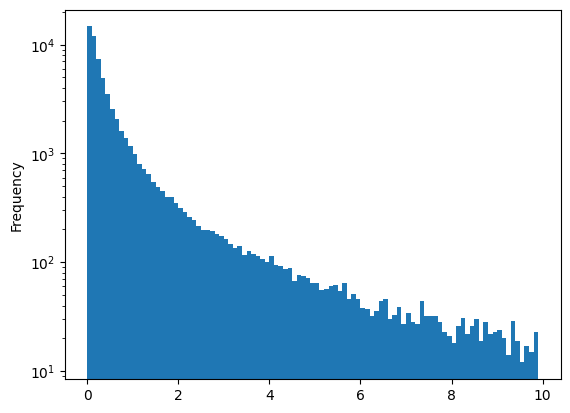

In [50]:
rel_diff.plot.hist(bins=np.arange(0, 10, 0.1))
# area_ratio.plot.hist(bins=np.linspace(-10, 10, 50))
plt.yscale("log")

In [52]:
# Write output
if GLAKES_tpcat_pth.exists():
    GLAKES_tpcat_pth.unlink()

glakes_matched.crs = glakes.crs
glakes_matched.to_file(GLAKES_tpcat_pth)

print(f"Wrote {len(glakes_matched)} lakes to {GLAKES_tpcat_pth}")
print(f"  - PLD matches: {glakes_matched['lake_id_tpcat'].notna().sum()}")
print(f"  - Share PLD: {glakes_matched['share_pld'].sum()}")

Wrote 1549717 lakes to /Volumes/metis/Datasets/Liu_aq_veg/figshare/v4/25012091/edk_out/GLAKES_tcat.gpkg
  - PLD matches: 1486346
  - Share PLD: 94476
